# NB07 — Diagnostic Plots: The Four You Should Always Run

> **StatQuest: "Before trusting any regression result, look at the residuals."**

---

## The four standard plots:

1. **Residuals vs Fitted** — checks L and E (linearity, equal variance)
2. **Normal Q-Q** — checks N (normality of residuals)
3. **Scale-Location** — checks E again (heteroscedasticity)
4. **Residuals vs Leverage** — finds influential points that distort the fit

These four plots are what R's `plot(lm())` produces automatically.


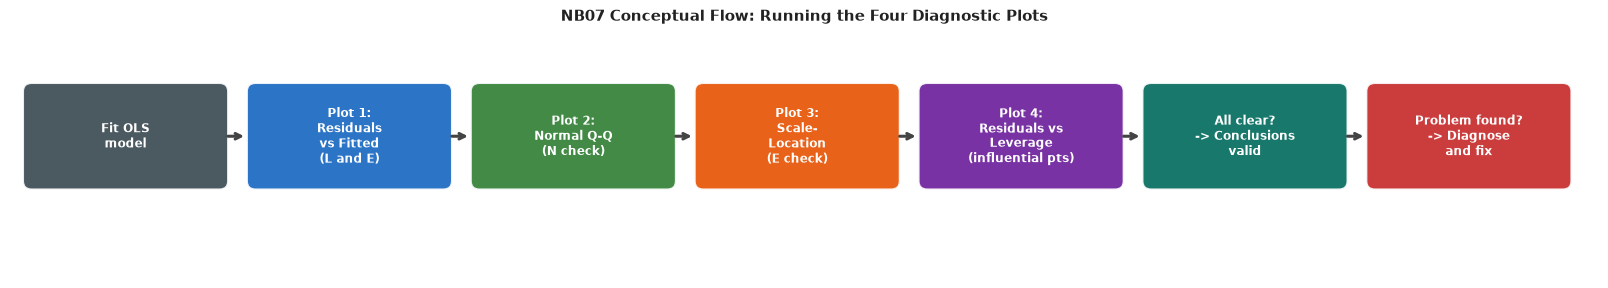

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

def flow_diagram(steps, title, colors=None, notes=None, figsize=(14, 2.8)):
    n = len(steps)
    default_colors = ['#1565C0','#2E7D32','#E65100','#6A1B9A',
                      '#00695C','#AD1457','#37474F','#4E342E',
                      '#0277BD','#558B2F','#C62828','#F57F17']
    colors = (colors or default_colors)[:n]
    notes  = notes or ['']*n
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.3, n*3.1); ax.set_ylim(-1.2, 2.4); ax.axis('off')
    bw, bh = 2.6, 1.3
    for i,(step,color,note) in enumerate(zip(steps,colors,notes)):
        x = i*3.1
        box = FancyBboxPatch((x,0.2),bw,bh,boxstyle="round,pad=0.12",
                             facecolor=color,edgecolor='white',linewidth=1.5,alpha=0.90)
        ax.add_patch(box)
        ax.text(x+bw/2,0.2+bh/2,step,ha='center',va='center',fontsize=8.5,
                color='white',fontweight='bold',multialignment='center')
        if note:
            ax.text(x+bw/2,0.02,note,ha='center',va='top',fontsize=7,
                    color='#555',style='italic')
        if i < n-1:
            ax.annotate('',xy=(x+bw+0.38,0.2+bh/2),xytext=(x+bw+0.08,0.2+bh/2),
                       arrowprops=dict(arrowstyle='->',color='#444',lw=2.2))
    ax.set_title(title,fontsize=11,fontweight='bold',pad=6,color='#222')
    plt.tight_layout(pad=0.4); plt.show()

flow_diagram(
    steps=[
        'Fit OLS\nmodel',
        'Plot 1:\nResiduals\nvs Fitted\n(L and E)',
        'Plot 2:\nNormal Q-Q\n(N check)',
        'Plot 3:\nScale-\nLocation\n(E check)',
        'Plot 4:\nResiduals vs\nLeverage\n(influential pts)',
        'All clear?\n-> Conclusions\nvalid',
        'Problem found?\n-> Diagnose\nand fix',
    ],
    title='NB07 Conceptual Flow: Running the Four Diagnostic Plots',
    colors=['#37474F','#1565C0','#2E7D32','#E65100','#6A1B9A','#00695C','#C62828'],
    figsize=(16, 2.8),
)


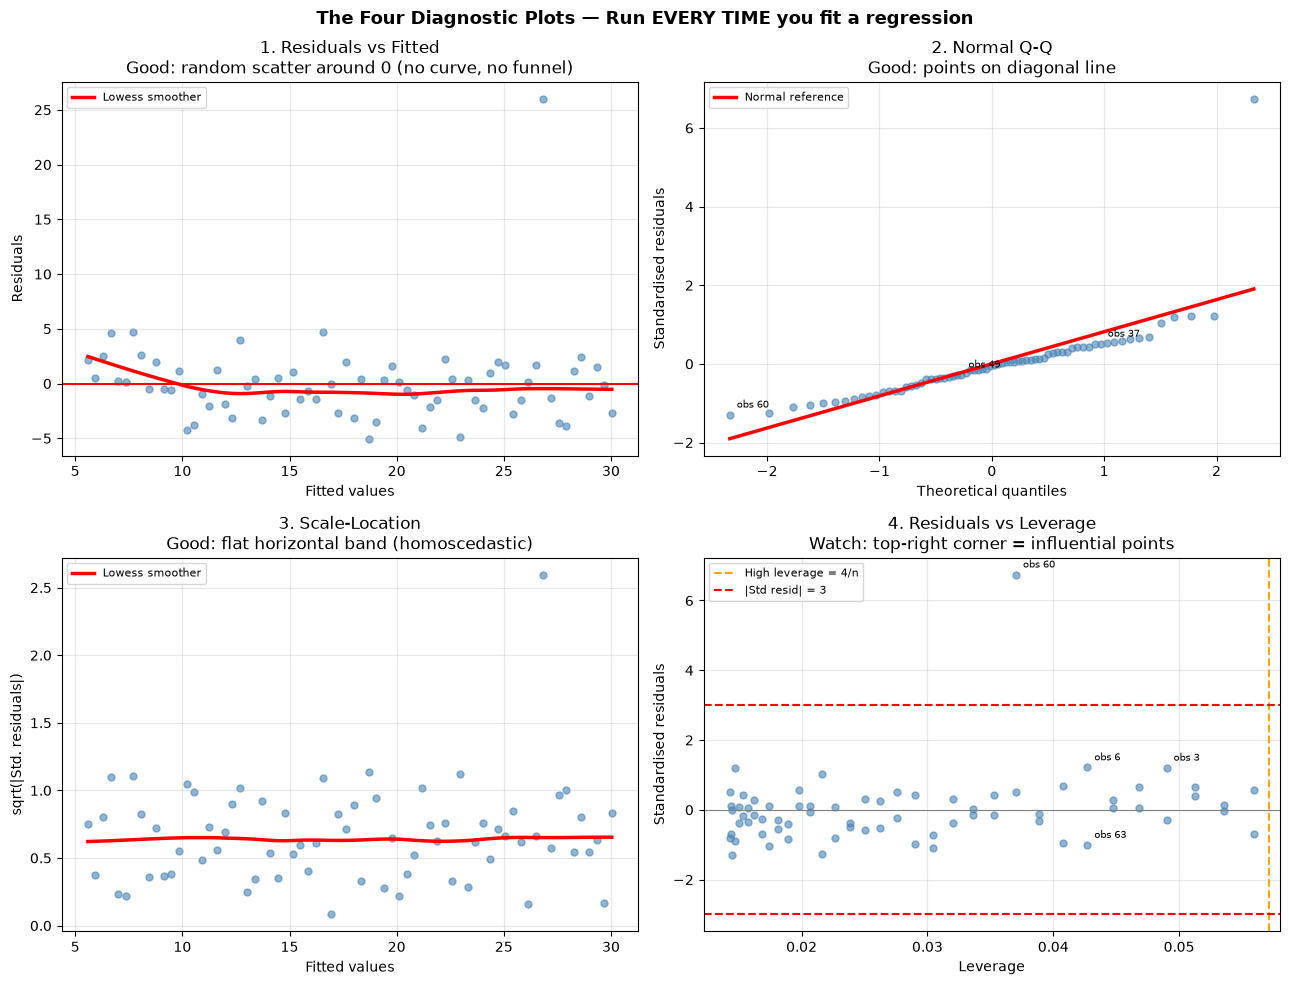

In [2]:
import numpy as np, matplotlib.pyplot as plt, scipy.stats as stats
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

np.random.seed(42)
n = 70
X_raw = np.linspace(1, 10, n)
y = 2.5*X_raw + 4 + np.random.normal(0, 2.5, n)
y[60] += 28    # inject one influential outlier

Xsm = sm.add_constant(X_raw)
result    = sm.OLS(y, Xsm).fit()
influence = result.get_influence()

fitted    = result.fittedvalues
resid     = result.resid
std_resid = influence.resid_studentized_internal
leverage  = influence.hat_matrix_diag
cooks_d   = influence.cooks_distance[0]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# ── Plot 1: Residuals vs Fitted ──────────────────────────────────────────────
ax = axes[0,0]
ax.scatter(fitted, resid, s=25, alpha=0.6, color='steelblue')
ax.axhline(0, color='red', linewidth=1.5)
lo = lowess(resid, fitted, frac=0.4)
ax.plot(lo[:,0], lo[:,1], 'r-', linewidth=2.5, label='Lowess smoother')
ax.set_xlabel('Fitted values'); ax.set_ylabel('Residuals')
ax.set_title('1. Residuals vs Fitted\nGood: random scatter around 0 (no curve, no funnel)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Plot 2: Normal Q-Q ────────────────────────────────────────────────────────
ax = axes[0,1]
(osm, osr), (slope, intercept, _) = stats.probplot(std_resid)
ax.scatter(osm, osr, s=25, alpha=0.6, color='steelblue')
xs = np.array([osm.min(), osm.max()])
ax.plot(xs, slope*xs+intercept, 'r-', linewidth=2.5, label='Normal reference')
for i in np.argsort(np.abs(std_resid))[-3:]:
    ax.annotate(f'obs {i}', (osm[np.argsort(std_resid)[i]], osr[np.argsort(std_resid)[i]]),
                textcoords='offset points', xytext=(5,5), fontsize=7)
ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Standardised residuals')
ax.set_title('2. Normal Q-Q\nGood: points on diagonal line')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Plot 3: Scale-Location ────────────────────────────────────────────────────
ax = axes[1,0]
sqrt_abs = np.sqrt(np.abs(std_resid))
ax.scatter(fitted, sqrt_abs, s=25, alpha=0.6, color='steelblue')
lo2 = lowess(sqrt_abs, fitted, frac=0.4)
ax.plot(lo2[:,0], lo2[:,1], 'r-', linewidth=2.5, label='Lowess smoother')
ax.set_xlabel('Fitted values'); ax.set_ylabel('sqrt(|Std. residuals|)')
ax.set_title('3. Scale-Location\nGood: flat horizontal band (homoscedastic)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Plot 4: Residuals vs Leverage ─────────────────────────────────────────────
ax = axes[1,1]
ax.scatter(leverage, std_resid, s=25, alpha=0.6, color='steelblue')
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(4/n, color='orange', linewidth=1.5, linestyle='--', label=f'High leverage = 4/n')
ax.axhline(3,  color='red', linewidth=1.5, linestyle='--', label='|Std resid| = 3')
ax.axhline(-3, color='red', linewidth=1.5, linestyle='--')
for i in np.argsort(cooks_d)[-4:]:
    ax.annotate(f'obs {i}', (leverage[i], std_resid[i]),
                textcoords='offset points', xytext=(5,5), fontsize=7)
ax.set_xlabel('Leverage'); ax.set_ylabel('Standardised residuals')
ax.set_title("4. Residuals vs Leverage\nWatch: top-right corner = influential points")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("The Four Diagnostic Plots — Run EVERY TIME you fit a regression",
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## How to read each plot — step by step

### Plot 1: Residuals vs Fitted
| Pattern | Meaning | Action |
|---------|---------|--------|
| Random scatter around y=0 | L and E both OK | None needed |
| U-shape or arch | Linearity violated | Add polynomial term |
| Funnel (wider on right) | Heteroscedasticity | Log-transform y or use WLS |

### Plot 2: Normal Q-Q
| Pattern | Meaning | Action |
|---------|---------|--------|
| Points on the diagonal | Normality OK | None needed |
| S-curve | Heavy tails | Robust regression |
| Skewed upward | Right skew | Log-transform y |

### Plot 3: Scale-Location
| Pattern | Meaning | Action |
|---------|---------|--------|
| Flat horizontal band | Homoscedastic | None needed |
| Rising band | Variance grows with fitted value | WLS, log(y) |

### Plot 4: Residuals vs Leverage (Cook's D)
| Zone | Meaning | Action |
|------|---------|--------|
| Low leverage + small residual | Normal point | None |
| High leverage + small residual | Unusual x, but fits well | Usually fine |
| Low leverage + large residual | Outlier in y (not influential) | Check for data error |
| **High leverage + large residual** | **Influential — changes the line!** | **Investigate carefully** |


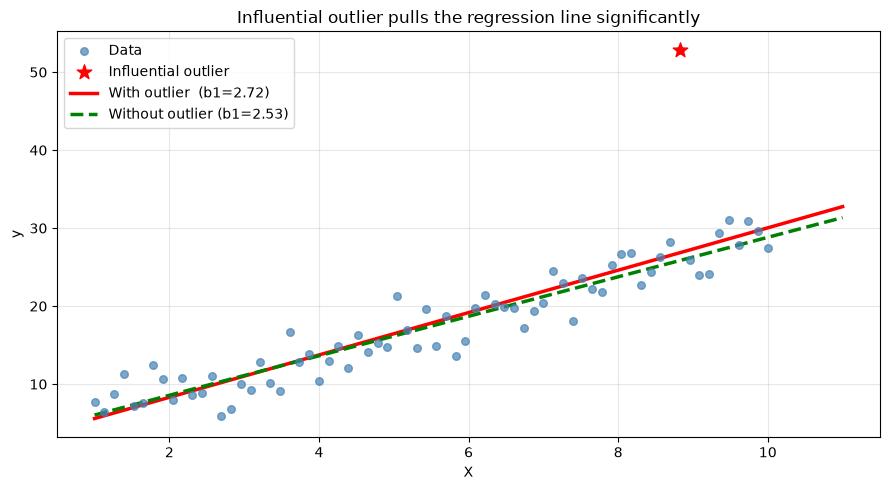

In [3]:
# Show what happens when you remove the influential point
import numpy as np, statsmodels.api as sm, matplotlib.pyplot as plt

mask_no_outlier = np.ones(n, dtype=bool)
mask_no_outlier[60] = False   # remove the injected outlier

Xsm_clean = sm.add_constant(X_raw[mask_no_outlier])
res_clean  = sm.OLS(y[mask_no_outlier], Xsm_clean).fit()

X_plot = np.linspace(1, 11, 200)
Xp_sm  = sm.add_constant(X_plot)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_raw, y, s=30, color='steelblue', alpha=0.7, label='Data', zorder=3)
ax.scatter([X_raw[60]], [y[60]], s=120, color='red', marker='*', zorder=4, label='Influential outlier')
ax.plot(X_plot, result.predict(Xp_sm),    'r-',  linewidth=2.5, label=f'With outlier  (b1={result.params[1]:.2f})')
ax.plot(X_plot, res_clean.predict(Xp_sm), 'g--', linewidth=2.5, label=f'Without outlier (b1={res_clean.params[1]:.2f})')
ax.set_xlabel('X'); ax.set_ylabel('y')
ax.set_title('Influential outlier pulls the regression line significantly')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Key Takeaways

| Plot | Assumption checked | Red flag |
|------|--------------------|----------|
| Residuals vs Fitted | Linearity (L), Equal variance (E) | Curve, funnel |
| Normal Q-Q | Normality (N) | Points off diagonal |
| Scale-Location | Equal variance (E) again | Rising trend |
| Residuals vs Leverage | Influential observations | Top-right cluster |

**Always run all four before reporting results.**

**Next: NB08 — Multiple regression: extend to many predictors.**
